In [1]:
# Set up sys.path so that 'src/spindle_dev' is importable as 'spindle_dev'
import sys
import importlib
from pathlib import Path

project_root = '/data/sarkar_lab/Projects/spindle_dev'
src_path = Path(project_root) / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import spindle_dev
# Reload to pick up code changes without restarting the kernel
importlib.reload(spindle_dev)

<module 'spindle_dev' from '/data/sarkar_lab/Projects/spindle_dev/src/spindle_dev/__init__.py'>

In [2]:
import scanpy as sc
import glob

In [3]:
h5ad_files = glob.glob("/data/sarkar_lab/insitupy_demo_data_xenium/*.h5ad")

In [4]:
import spindle_dev
import spindle_dev.metrics as metrics
import spindle_dev.index as index
import spindle_dev.preprocessing as preprocessing
import spindle_dev.plotting as plotting
import spindle_dev.test as test
import spindle_dev.search as search
import spindle_dev.typing as typing
import time

In [5]:
from pathlib import Path

In [6]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from joblib import Parallel, delayed
import argparse
import pandas as pd

In [7]:
def create_index(adata, resolution=0.5, min_final_size=10, top_genes=200, n_queries = 2000, all_genes=False):
    # start time 
    
    # Create index directory if it doesn't exist
    #Path(index_path).mkdir(parents=True, exist_ok=True)

    start_time = time.time()
    
    coords = adata.obsm["spatial"]
    tiles = preprocessing.build_quadtree_tiles(coords, max_pts=200, min_side=0.0, max_depth=40)
    # remove tiles with less than 5 spots
    tiles = [tile for tile in tiles if len(tile.idx) >= 5]
    tiles = preprocessing.reindex_tiles(tiles)
    if all_genes:
        num_genes = adata.n_vars
    else:
        num_genes = top_genes
    genes_work, gene_idx = spindle_dev.preprocessing.topvar_genes(adata, G=num_genes)  
    tile_covs = spindle_dev.preprocessing.build_tile_covs_full_serial(adata, tiles, gene_idx, eps=1e-6)
    data = index.ProcessedData(tiles, tile_covs, genes_work, adata.n_obs)
    if 'pca' not in data.latent:
        data.reduce_dim(num_pca_components=30, n_components=2, do_umap=True)
    data.cluster_spds(cluster_distance="tree", cluster_method="leiden", resolution=resolution)
    data.assign_label_to_spots()
    data.get_corr_mean_by_cluster()
    out_dict = data.get_adaptive_runs(find_blocks=True, with_size_guard=True,min_final_size=min_final_size,max_final_size=100)
    epsilon_block_wise_dict = {}
    epsilon_dict = {}
    for cluster_id in set(data.labels):
        eps_per_block, eps_elbow_per_block, eps = index.choose_adaptive_epsilons(data, cluster_id, k_target_per_block=64)
        epsilon_block_wise_dict[int(cluster_id)] = eps_elbow_per_block
        epsilon_dict[int(cluster_id)] = eps

    # Create indices config
    config = typing.IndexConfig()
    config.epsilon_dict = epsilon_dict
    config.epsilon_block_wise_dict = epsilon_block_wise_dict
    config.threshold_type = 'constant'
    config.kmean_method = 'epsilon_net' 
    dag_dict, stat, dist_list = index.index_spds(data, config=config)


    seed = 40
    rng = np.random.default_rng(seed)
    all_indices = np.arange(len(data.spd_matrices))
    valid_clusters = list(dag_dict.keys())
    mask = np.isin(data.labels, valid_clusters)
    candidate_indices = all_indices[mask]
    
    query_indices = rng.choice(candidate_indices, size=n_queries, replace=False)

    dag_dict, stat, dist_list = index.index_spds(data, config=config)
    gt_paths = test.create_ground_truth_paths(dag_dict)
    query_matrices = [data.spd_matrices[i] for i in query_indices]



    true_clusters = [int(data.labels[i]) for i in query_indices]
    predicted_clusters = search.assign_clusters_to_new_spds(query_matrices, data)
    predicted_df = pd.DataFrame({'True Cluster': true_clusters, 'Predicted Cluster': predicted_clusters})
    print(f"Done with search")
    return predicted_df


In [8]:
all_df = []
for h5ad_file in h5ad_files:
    if '5k' not in h5ad_file:
        adata = sc.read_h5ad(h5ad_file)
        experiment_name = h5ad_file.split("/")[-1].replace(".h5ad", "")
        print(experiment_name)
        predicted_df = create_index(adata, all_genes =True, n_queries=10)
        predicted_df['experiment_name'] = experiment_name
        all_df += [predicted_df]
        del adata

xenium_human_skin_melanoma


[2026-01-20 12:41:00,009] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-01-20 12:41:00,131] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-01-20 12:41:42,003] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-01-20 12:41:42,726] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-01-20 12:41:55,062] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.0594365  0.04257701 0.02694363 0.02286748 0.01322526 0.00847291
 0.00765662 0.00680464 0.00621679 0.00598492 0.0054304  0.00475169
 0.00459882 0.00427495 0.00419172 0.00405914 0.00396039 0.00382956
 0.00374104 0.00359517 0.00349659 0.00337946 0.00327844 0.00323106
 0.00320595 0.00311978 0.00309778 0.00301003 0.00297968 0.00291783]
[2026-01-20 12:41:55,070] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
/panfs/accrepfs.vampire/home/sarkah1/miniforge3/envs/spatial/lib/py

Done with search
xenium_human_brain_cancer


[2026-01-20 12:43:25,468] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-01-20 12:43:25,471] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
/panfs/accrepfs.vampire/home/sarkah1/miniforge3/envs/spatial/lib/python3.10/site-packages/scipy/cluster/hierarchy.py:1673: RuntimeWarning: invalid value encountered in scalar divide
  c = xp.sum(numerator) / xp.sqrt(xp.sum(denomA) * xp.sum(denomB))
[2026-01-20 12:46:20,963] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-01-20 12:46:34,702] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-01-20 12:47:20,029] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.03411894 0.02578561 0.01285703 0.00938737 0.00588084 0.00551661
 0.00453925 0.00377464 0.00356478 0.00307318 0.00273169 0.0026462
 0.00263546 0.00248134 0.00241321 0.00210543 0.00208783 0.00205712
 0.0020324  0.00196088 0.00191746 0.00189922 0.00186625 0

Done with search
xenium_human_kidney_nondiseased


...

Done with search
xenium_human_pancreatic_cancer


[2026-01-20 13:02:39,271] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-01-20 13:02:39,272] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-01-20 13:05:38,285] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-01-20 13:05:40,347] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-01-20 13:06:00,263] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.0320497  0.02162234 0.01256116 0.01050905 0.00749142 0.00605011
 0.00554716 0.00489446 0.00464791 0.00400857 0.00364074 0.00334745
 0.00303675 0.00288334 0.00285155 0.00278616 0.00268314 0.00255294
 0.00253779 0.0024637  0.00244129 0.00239347 0.00235185 0.00232927
 0.00231797 0.00226505 0.00223933 0.00221084 0.00216073 0.0021491 ]
[2026-01-20 13:06:00,265] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
/panfs/accrepfs.vampire/home/sarkah1/miniforge3/envs/spatial/lib/py

Done with search
xenium_human_breast_cancer


[2026-01-20 13:08:34,255] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.
[2026-01-20 13:08:34,257] INFO spindle_dev.index: Building ultrametric features from SPD matrices.
[2026-01-20 13:09:37,705] INFO spindle_dev.index: Computing latent features from the tree representations.
[2026-01-20 13:09:38,451] INFO spindle_dev.index: Reducing latent features to 30 dimensions using PCA.
[2026-01-20 13:09:49,992] INFO spindle_dev.index: Explained variance ratios by PCA components: [0.08423994 0.05705022 0.02586921 0.01825469 0.01257789 0.00976704
 0.00760607 0.00706846 0.00636611 0.00628477 0.00481051 0.00461066
 0.00410269 0.00399039 0.00367698 0.00352124 0.00345466 0.0033279
 0.00319359 0.00302569 0.00300604 0.0029441  0.00289233 0.00285734
 0.00284254 0.00280568 0.00273195 0.00266459 0.00263317 0.00257663]
[2026-01-20 13:09:49,994] INFO spindle_dev.index: Reducing latent features to 2 dimensions using UMAP.
/panfs/accrepfs.vampire/home/sarkah1/miniforge3/envs/spatial/lib/pyt

Done with search


In [9]:
# Merge all dataframes and save to CSV
merged_df = pd.concat(all_df, ignore_index=True)
# output_path = '/data/sarkar_lab/Projects/spindle_dev/results/cross_cluster_search_performance.csv'
# merged_df.to_csv(output_path, index=False)
# print(f"Saved results to {output_path}")
# print(f"Total rows: {len(merged_df)}")
merged_df.head()

,True Cluster,Predicted Cluster,experiment_name
0,2,2,xenium_human_skin_melanoma
1,5,5,xenium_human_skin_melanoma
2,3,3,xenium_human_skin_melanoma
3,4,4,xenium_human_skin_melanoma
4,0,0,xenium_human_skin_melanoma


In [1]:
import pandas as pd

In [2]:
merged_result = pd.read_csv('/data/sarkar_lab/Projects/spindle_dev/results/search_results/cross_cluster_search_performance.csv')

In [4]:
# Find out group by accuracy 
accuracy_df = merged_result.groupby('experiment_name').apply(lambda x: (x['True Cluster'] == x['Predicted Cluster']).mean()).reset_index()
accuracy_df.columns = ['experiment_name', 'accuracy']
accuracy_df = accuracy_df.sort_values(by='accuracy', ascending=False)
accuracy_df

/tmp/ipykernel_4169152/4153229215.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_df = merged_result.groupby('experiment_name').apply(lambda x: (x['True Cluster'] == x['Predicted Cluster']).mean()).reset_index()


,experiment_name,accuracy
1,xenium_human_breast_cancer,0.990
3,xenium_human_lung_cancer,0.960
0,xenium_human_brain_cancer,0.955
6,xenium_human_skin_melanoma,0.955
4,xenium_human_lymph_node,0.945
5,xenium_human_pancreatic_cancer,0.935
2,xenium_human_kidney_nondiseased,0.920


In [6]:
short_name_map = {
    'xenium_human_skin_melanoma': 'Skin',
    'xenium_human_kidney_nondiseased': 'Kidney',
    'xenium_human_breast_cancer': 'Breast',
    'xenium_human_pancreatic_cancer': 'Pancreas',
    'xenium_human_lymph_node': 'Lymph',
    'xenium_human_lung_cancer': 'Lung',
    'xenium_human_brain_cancer': 'Brain'
}


In [8]:
accuracy_df['experiment_name'] = accuracy_df.experiment_name.map(short_name_map)

In [18]:
from pathlib import Path
Path('/data/sarkar_lab/Projects/spindle_dev/results/plots/').mkdir(parents=True, exist_ok=True)

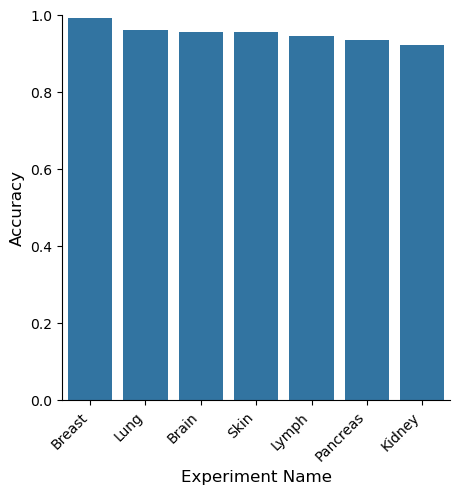

In [20]:
# do barplot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.barplot(data=accuracy_df, x='experiment_name', y='accuracy')
plt.ylim(0, 1)
# roate x labels
plt.xticks(rotation=45, ha='right')
plt.xlabel('Experiment Name',fontsize=12)
plt.ylabel('Accuracy',fontsize=12)
plt.title('')
sns.despine()

plt.savefig('/data/sarkar_lab/Projects/spindle_dev/results/plots/cross_cluster_search_performance_barplot.png', dpi=300, bbox_inches='tight')
plt.show()